In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Dice Loss
def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

# Dice Metric
def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    y_pred_f = tf.cast(y_pred_f > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/lung_segmentation_baseline.h5",
    custom_objects={
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient
    }
)

print("Baseline model loaded successfully!")

Baseline model loaded successfully!


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

In [ ]:
def load_nodule(nodule_path):
    image_folder = os.path.join(nodule_path, "images")
    mask_folders = [os.path.join(nodule_path, m)
                    for m in os.listdir(nodule_path) if "mask" in m]

    images = []
    masks = []

    image_files = sorted(os.listdir(image_folder))

    for img_file in image_files:
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        images.append(img)

        combined_mask = np.zeros_like(img)

        for mask_folder in mask_folders:
            mask_path = os.path.join(mask_folder, img_file)
            if os.path.exists(mask_path):
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                combined_mask = np.maximum(combined_mask, mask)

        masks.append(combined_mask)

    return np.array(images), np.array(masks)


def normalize_images(images):
    images = images.astype(np.float32) / 255.0
    return images


def resize_images(images, masks, size=(128,128)):
    resized_images = []
    resized_masks = []

    for img, mask in zip(images, masks):
        img_resized = cv2.resize(img, size)
        mask_resized = cv2.resize(mask, size)

        resized_images.append(img_resized)
        resized_masks.append(mask_resized)

    return np.array(resized_images), np.array(resized_masks)

In [ ]:
from google.colab import files
from tqdm import tqdm

uploaded = files.upload()  # shows upload progress UI

In [ ]:
import zipfile
from tqdm import tqdm

zip_path = list(uploaded.keys())[0]
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()

    for file in tqdm(file_list, desc="Extracting"):
        zip_ref.extract(file, extract_path)

print("Extraction complete!")

Extracting: 100%|██████████| 77740/77740 [00:08<00:00, 9546.14it/s]

Extraction complete!


In [ ]:
import os
import numpy as np
import cv2
import tensorflow as tf

In [ ]:

dataset_path = "dataset/LIDC-IDRI-slices"  # change if needed

all_volumes = []
all_masks = []

for patient in os.listdir(dataset_path):
    patient_path = os.path.join(dataset_path, patient)

    if not os.path.isdir(patient_path):
        continue

    for nodule in os.listdir(patient_path):
        nodule_path = os.path.join(patient_path, nodule)

        if not os.path.isdir(nodule_path):
            continue

        try:
            images, masks = load_nodule(nodule_path)
            images = normalize_images(images)
            images, masks = resize_images(images, masks)

            all_volumes.append(images)
            all_masks.append(masks)

        except Exception as e:
            print("Skipping:", nodule_path, "Error:", e)

print("Total Nodules Loaded:", len(all_volumes))

Total Nodules Loaded: 2630


In [ ]:
TARGET_DEPTH = 8

def pad_depth(volume):
    depth = volume.shape[0]

    if depth >= TARGET_DEPTH:
        return volume[:TARGET_DEPTH]

    pad_before = (TARGET_DEPTH - depth) // 2
    pad_after = TARGET_DEPTH - depth - pad_before

    return np.pad(volume,
                  ((pad_before, pad_after), (0,0), (0,0)),
                  mode='constant')


X = np.array([pad_depth(v) for v in all_volumes])
Y = np.array([pad_depth(m) for m in all_masks])

# Add channel dimension
X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2630, 8, 128, 128, 1)
Y shape: (2630, 8, 128, 128, 1)


In [ ]:
Y = (Y > 0).astype(np.float32)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [ ]:
def compute_dice(y_true, y_pred):
    smooth = 1e-6
    y_true_f = y_true.flatten()
    y_pred_f = (y_pred > 0.5).astype(np.float32).flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2.*intersection + smooth) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + smooth
    )

# Predict
pred_baseline = model.predict(X_val)

dice_scores = [compute_dice(Y_val[i], pred_baseline[i]) for i in range(len(X_val))]
baseline_dice = np.mean(dice_scores)

print("Baseline Dice:", baseline_dice)

17/17 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step
Baseline Dice: 0.4456651


In [ ]:
def augment(volume, mask):

    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=2)
        mask = np.flip(mask, axis=2)

    if np.random.rand() > 0.5:
        volume = np.flip(volume, axis=1)
        mask = np.flip(mask, axis=1)

    if np.random.rand() > 0.5:
        noise = np.random.normal(0, 0.02, volume.shape)
        volume = volume + noise

    return volume, mask

In [ ]:
def data_generator(X, Y, batch_size=4):
    while True:
        idx = np.random.randint(0, len(X), batch_size)

        batch_X, batch_Y = [], []

        for i in idx:
            v, m = augment(X[i], Y[i])
            batch_X.append(v)
            batch_Y.append(m)

        yield np.array(batch_X), np.array(batch_Y)

In [ ]:
model_aug = model

In [ ]:
history_aug = model_aug.fit(
    data_generator(X_train, Y_train, batch_size=4),
    validation_data=(X_val, Y_val),
    steps_per_epoch=len(X_train)//4,
    epochs=20
)

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 365s 618ms/step - dice_coefficient: 0.6306 - loss: 0.4961 - val_dice_coefficient: 0.6908 - val_loss: 0.3917
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 322s 611ms/step - dice_coefficient: 0.6560 - loss: 0.4252 - val_dice_coefficient: 0.6946 - val_loss: 0.3540
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 322s 612ms/step - dice_coefficient: 0.6914 - loss: 0.3545 - val_dice_coefficient: 0.7041 - val_loss: 0.3256
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 321s 611ms/step - dice_coefficient: 0.6752 - loss: 0.3556 - val_dice_coefficient: 0.6962 - val_loss: 0.3230
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 322s 613ms/step - dice_coefficient: 0.6860 - loss: 0.3341 - val_dice_coefficient: 0.7124 - val_loss: 0.3026
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 322s 613ms/step - dice_coefficient: 0.7134 - loss: 0.3010 - val_dice_coefficient: 0.6802 - val_loss: 0.3261
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 323s 614ms/step - dice_coefficient: 0.7110 - loss: 0.2990 - val_dice_coe

In [ ]:
# Save full trained augmented model
model.save("/content/drive/MyDrive/lung_segmentation_augmented.h5")

print("Augmented model saved successfully!")

Augmented model saved successfully!


In [ ]:
pred_aug = model_aug.predict(X_val)

dice_scores_aug = [
    compute_dice(Y_val[i], pred_aug[i]) for i in range(len(X_val))
]

aug_dice = np.mean(dice_scores_aug)

print("Augmented Dice:", aug_dice)

17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step
Augmented Dice: 0.6643345


In [ ]:
print("\n===== FINAL COMPARISON =====")
print(f"Baseline Dice : {baseline_dice:.4f}")
print(f"Augmented Dice: {aug_dice:.4f}")


===== FINAL COMPARISON =====
Baseline Dice : 0.4457
Augmented Dice: 0.6643


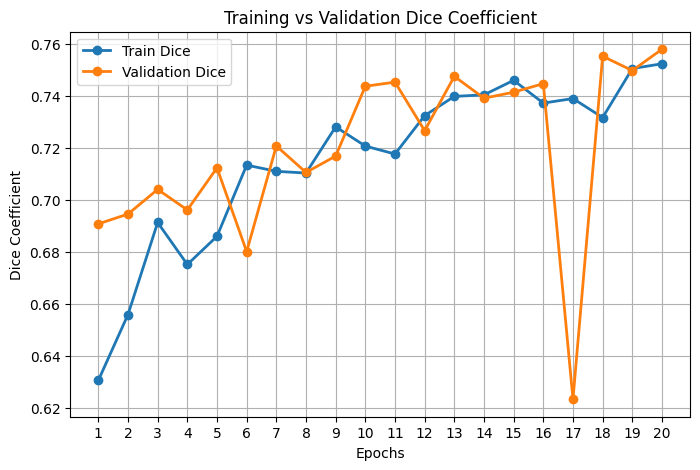

In [ ]:

import matplotlib.pyplot as plt

epochs = range(1, len(history_aug.history['loss']) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, history_aug.history['dice_coefficient'], label='Train Dice', marker='o', linewidth=2)
plt.plot(epochs, history_aug.history['val_dice_coefficient'], label='Validation Dice', marker='o', linewidth=2)

plt.title("Training vs Validation Dice Coefficient")
plt.xlabel("Epochs")
plt.ylabel("Dice Coefficient")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

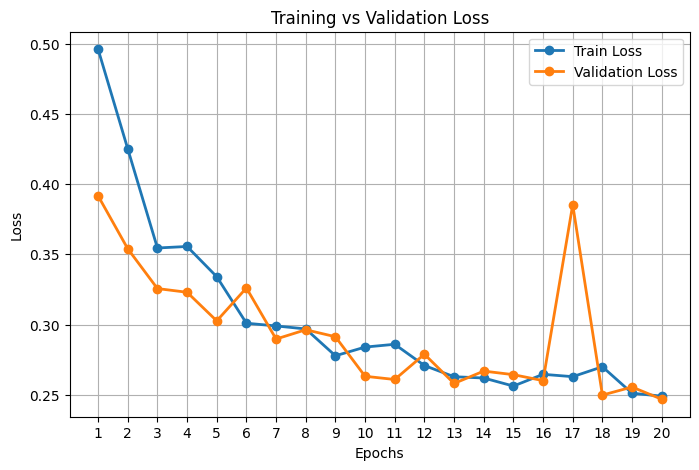

In [ ]:

plt.figure(figsize=(8,5))
plt.plot(epochs, history_aug.history['loss'], label='Train Loss', marker='o', linewidth=2)
plt.plot(epochs, history_aug.history['val_loss'], label='Validation Loss', marker='o', linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()

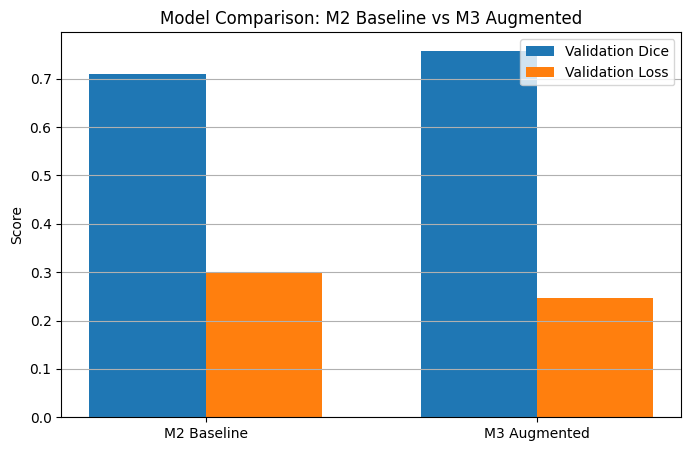

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

models = ['M2 Baseline', 'M3 Augmented']

# Replace baseline values with your actual M2 results
dice_scores = [0.71, 0.7580]
loss_scores = [0.30, 0.2470]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, dice_scores, width, label='Validation Dice')
plt.bar(x + width/2, loss_scores, width, label='Validation Loss')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Comparison: M2 Baseline vs M3 Augmented")
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
# Copy your zip file from session storage to Google Drive
import shutil

shutil.copy(
    '/content/archive (2).zip',
    '/content/drive/MyDrive/LungTumour/lung_tumor.zip'
)

'/content/drive/MyDrive/LungTumour/lung_tumor.zip'